In [2]:
import numpy as np
import pandas as pd
import arviz as az
from scipy import stats
from matplotlib import pyplot as plt
from matplotlib import patches
from cmdstanpy import CmdStanModel
from sampler import CycloneSampler, CycloneDataSimulator

In [ ]:
def plot_parameter_estimation_stan(draws_df, DataSimulator, param_names, N_obs):

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]

    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])

    # plot convergence for large data set
    all_param_draws = []
    unscaled_param_draws = []
    param_stds = []
    for param, true in zip(param_names, true_params_flat):
        # normalizes the draws so that they can all be plotted together
        draws = draws_df[param].values[:]
        unscaled_param_draws.append(draws)
        standardized_draws = (draws - true) / draws.std()
        all_param_draws.append(standardized_draws)
        param_stds.append(draws.std())

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"Convergence of Posterior Parameter Draws in Stan, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)
    ax = fig.add_subplot(111)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        # showmeans=True,
        # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
        
    plt.show()

    return true_params_flat, np.array(unscaled_param_draws)


def plot_parameter_estimation_mcmc(Sampler, DataSimulator, param_names, N_obs):
    N_samples = len(Sampler.alpha_draws)

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]
    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])
    all_param_draws = np.vstack([
        Sampler.sig2_draws.T,
        Sampler.Beta_draws.reshape(N_samples, -1).T,
        Sampler.tau2_draws.T,
        Sampler.alpha_draws, 
        Sampler.gamma_draws,
        Sampler.nu_draws.T,
        Sampler.lam_draws.T,
    ])

    unscaled_param_draws = all_param_draws.copy()

    param_stds = all_param_draws.std(axis=1)
    all_param_draws = ((all_param_draws.T - true_params_flat) / param_stds).T

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"Convergence of Posterior Parameter Draws in MCMC, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)
    ax = fig.add_subplot(111)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws.T,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
        
    plt.show()

    return true_params_flat, unscaled_param_draws


def compare_posterior_draws(MCMC_draws, Stan_draws, true_params, param_names, figsize=(14, 7)):

    n_params = len(true_params)
    positions = np.arange(n_params)
    labels = ["MCMC Draws", "Stan Draws"]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    for i, (mcmc_draw, stan_draw) in enumerate(zip(MCMC_draws, Stan_draws)):

        if true_params is not None:
            ref_val = true_params[i]
            # offset plot slightly left/right from the reference
            vp_mcmc = ax.violinplot([mcmc_draw - ref_val], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw - ref_val], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
        else:
            vp_mcmc = ax.violinplot([mcmc_draw], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)            
        
        # style the violin plots for each sampler
        for pc in vp_mcmc["bodies"]:
            pc.set_facecolor("#1f77b4")
            pc.set_alpha(0.5)
        vp_mcmc["cmeans"].set_color("#1f77b4")

        for pc in vp_stan["bodies"]:
            pc.set_facecolor("#ff7f0e")
            pc.set_alpha(0.5)
        vp_stan["cmeans"].set_color("#ff7f0e")

    # mark the reference values (0 because we centered the plot)
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="True value", zorder=5)

    # set ticks and labels
    ax.set_xticks(positions)
    ax.set_xticklabels(param_names, rotation=90)
    ax.set_ylabel("Deviation from True Value")
    ax.set_title("Posterior Sample Comparison")

    ax.set_ylim(-8, 8)

    legend_handles = [
        patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
        patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
        plt.Line2D([0], [0], color='black', linestyle='--', label='True value')
    ]

    ax.legend(handles=legend_handles)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig, ax

Test whether our MCMC implementation converges to the same parameters as the Stan model when given simulated data.

In [2]:
# prior parameters (for sampling data)
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

In [10]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]

In [5]:
N = 1000             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [6]:
# load Stan sampler
StanSampler = CmdStanModel(stan_file="conjugate_model.stan")

# initialize our own MCMC sampler
MCMCSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)

In [7]:
# sample using Stan
fit = StanSampler.sample(stan_data, iter_warmup=1000, iter_sampling=10_000)
stan_draws_df = fit.draws_pd()

09:56:45 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/11000 [00:00<?, ?it/s, (Warmup)]





chain 1:   1%|          | 100/11000 [00:01<03:29, 52.06it/s, (Warmup)]


chain 1:   2%|▏         | 200/11000 [00:03<02:36, 68.90it/s, (Warmup)]


chain 1:   3%|▎         | 300/11000 [00:03<02:07, 84.13it/s, (Warmup)]


chain 1:   4%|▎         | 400/11000 [00:04<01:47, 98.39it/s, (Warmup)]


chain 1:   5%|▍         | 500/11000 [00:05<01:39, 105.17it/s, (Warmup)]


chain 1:   5%|▌         | 600/11000 [00:06<01:32, 112.82it/s, (Warmup)]


chain 1:   6%|▋         | 700/11000 [00:06<01:24, 122.28it/s, (Warmup)]


chain 1:   7%|▋         | 800/11000 [00:07<01:19, 128.27it/s, (Warmup)]


chain 1:   8%|▊         | 900/11000 [00:08<01:16, 131.50it/s, (Warmup)]





chain 1:   9%|▉         | 1000/11000 [00:09<01:23, 120.16it/s, (Sampling)]


chain 1:  10%|█         | 1100/11000 [00:10<01:24, 117.03it/s, (Sampling)]


chain 1:  11%|█         | 1200/11000 [00:11<01:26, 113.45it/


09:58:41 - cmdstanpy - INFO - CmdStan done processing.
09:58:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Shape parameter is inf, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


In [8]:
MCMCSampler.sample(30_000, init_state=real_params)

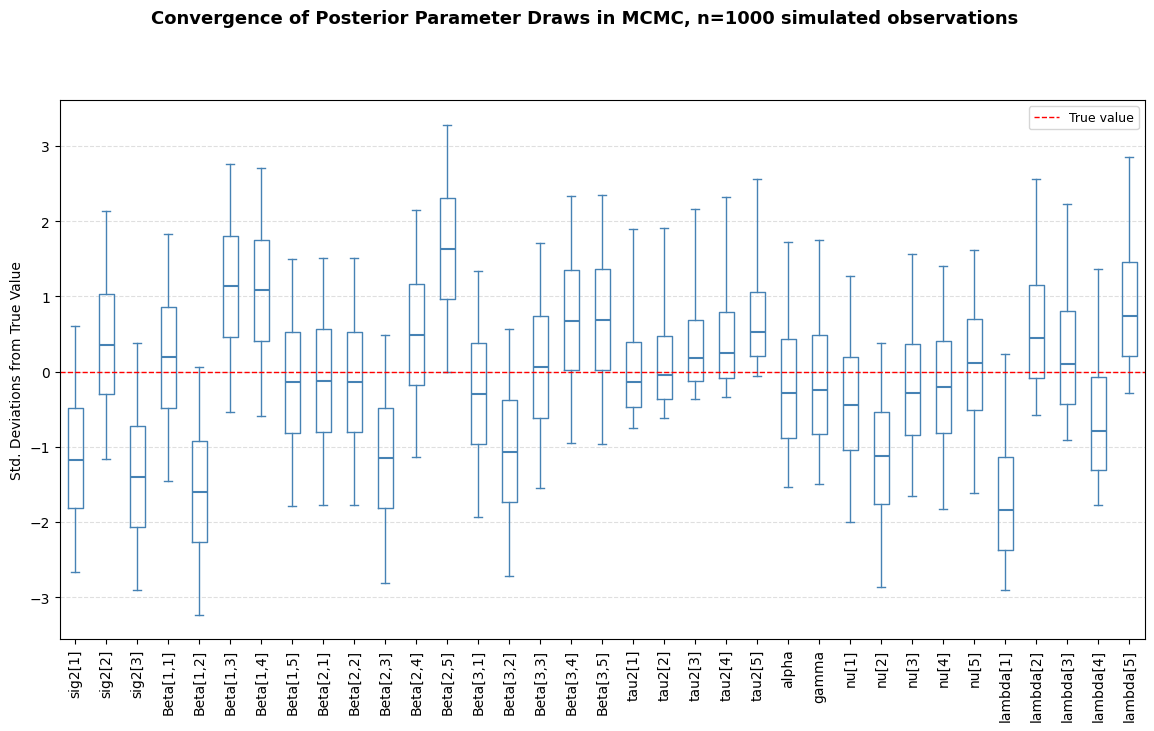

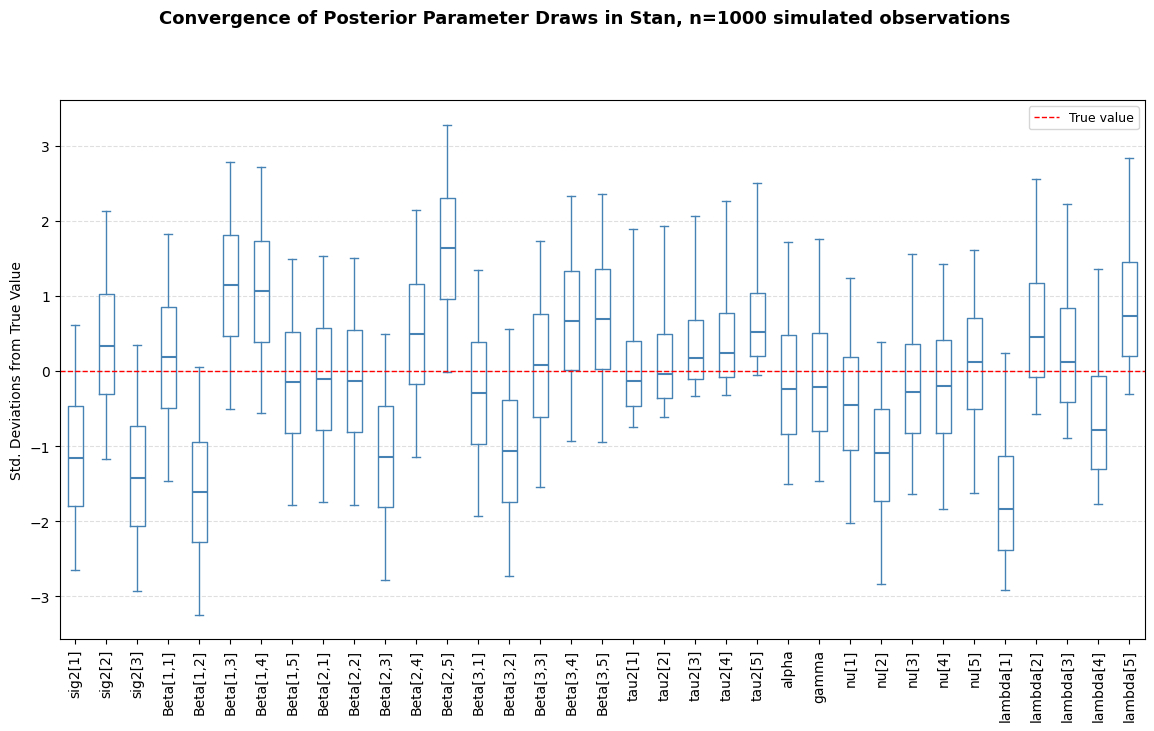

In [16]:
true_params, MCMC_draws = plot_parameter_estimation_mcmc(MCMCSampler, DataSimulator, param_names, N)
_, Stan_draws = plot_parameter_estimation_stan(stan_draws_df, DataSimulator, param_names, N)

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Posterior Sample Comparison'}, ylabel='Deviation from True Value'>)

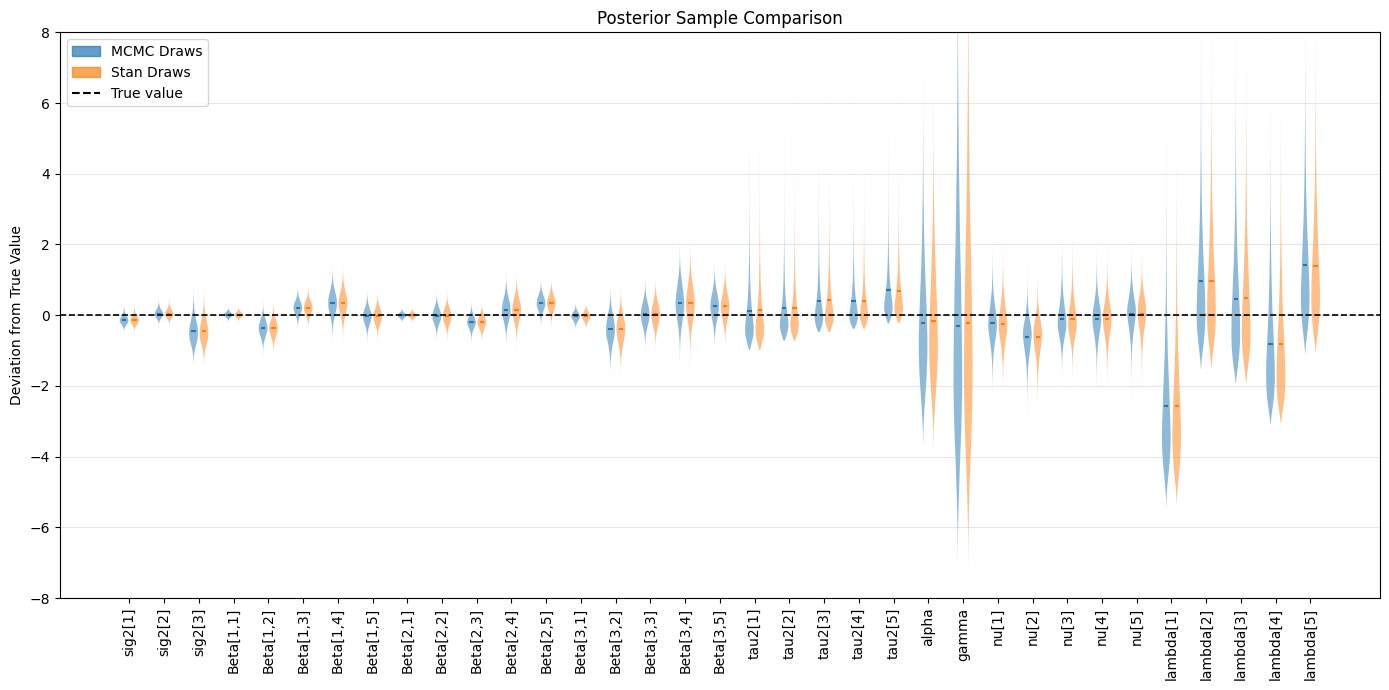

In [30]:
compare_posterior_draws(MCMC_draws, Stan_draws, true_params, param_names)

Before testing the models on real data, use the data simulator to look for good prior parameters.
Without looking at the data:
- Info I found on Google tells me that tropical typhoons have max wind speeds above 65 knots, with major tropical cyclones sometimes recording wind speeds up to 120 knots. Since we are assuming the log of the max wind speed is normally distributed, I want to choose prior parameters consistent with producting a normal distribution centered around roughly 4.5 (log(90)).

In [4]:
# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 225.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

N = 1000             # number of observations

# simulate N observations from the model
CalibratedDataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
CalibratedDataSimulator.generate_X(N_sim=N)
X = CalibratedDataSimulator.X 
basins = CalibratedDataSimulator.basins
W = CalibratedDataSimulator.simulate()

# save real parameters
real_params = [
    CalibratedDataSimulator.sig2,
    CalibratedDataSimulator.Beta,
    CalibratedDataSimulator.tau2,
    CalibratedDataSimulator.alpha, 
    CalibratedDataSimulator.gamma,
    CalibratedDataSimulator.nu,
    CalibratedDataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

Compare convergence of Stan and MCMC on real data.

In [5]:
# load data 
data = pd.read_csv("../processed_data/processed_data.csv")
# create basin index column
data["BasinIDX"] = data[["AL", "CP", "EP"]].values.argmax(axis=1)
predictor_cols = ["ONI", "logVMAX12", "MSLP12", "POT12", "VGRAD6-12"]     # are these the right columns??
X, W = data[predictor_cols].to_numpy(), data["logVMAX36"].to_numpy()
basins = data["BasinIDX"].to_numpy()
stan_basins = basins + 1

In [6]:
# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = len(set(stan_basins))               # number of ocean basins
D = X.shape[1]                          # number of predictors
N = len(W)                              # number of observations

# data for Stan
stan_data = {
    "N" : int(N), "B" : int(B), "D" : int(D),
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [7]:
# load Stan sampler
StanSampler = CmdStanModel(stan_file="conjugate_model.stan")

In [8]:
# sample using Stan
fit = StanSampler.sample(stan_data, iter_warmup=1000, iter_sampling=10_000)
stan_draws_df = fit.draws_pd()

19:26:25 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/11000 [00:00<?, ?it/s, (Warmup)]




chain 1:   1%|          | 100/11000 [00:00<00:14, 741.67it/s, (Warmup)]


chain 1:   2%|▏         | 200/11000 [00:05<05:25, 33.13it/s, (Warmup)] 


chain 1:   3%|▎         | 300/11000 [00:11<08:07, 21.96it/s, (Warmup)]


chain 1:   4%|▎         | 400/11000 [00:18<09:33, 18.49it/s, (Warmup)]


chain 1:   5%|▍         | 500/11000 [00:29<12:51, 13.62it/s, (Warmup)]


chain 1:   5%|▌         | 600/11000 [00:35<12:21, 14.03it/s, (Warmup)]


chain 1:   6%|▋         | 700/11000 [00:43<12:30, 13.72it/s, (Warmup)]


chain 1:   7%|▋         | 800/11000 [00:51<12:39, 13.43it/s, (Warmup)]


chain 1:   8%|▊         | 900/11000 [01:02<14:30, 11.60it/s, (Warmup)]






chain 1:   9%|▉         | 1000/11000 [01:11<14:22, 11.59it/s, (Sampling)]



chain 1:  10%|█         | 1100/11000 [01:18<13:48, 11.95it/s, (Sampling)]


chain 1:  11%|█         | 1200/11000 [01:26<13:24, 12.19it/s, (S


19:42:35 - cmdstanpy - INFO - CmdStan done processing.
19:42:35 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


19:42:40 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 9969 iterations at max treedepth (99.7%)
	Chain 2 had 9999 iterations at max treedepth (100.0%)
	Chain 3 had 9969 iterations at max treedepth (99.7%)
	Chain 4 had 9994 iterations at max treedepth (99.9%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [9]:
stan_draws_df

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,log_lik[1117],log_lik[1118],log_lik[1119],log_lik[1120],log_lik[1121],log_lik[1122],log_lik[1123],log_lik[1124],log_lik[1125],log_lik[1126]
0,1.0,1.0,1.0,1177.6018,0.459101,0.003007,10.0,1023.0,0.0,-1157.2647,...,0.173584,0.491495,-2.399227,0.327622,0.513704,0.303034,-1.299939,0.528424,0.602128,-0.734992
1,1.0,2.0,2.0,1177.5158,0.693264,0.003007,10.0,1023.0,0.0,-1159.2837,...,0.216489,0.473806,-2.589551,0.312032,0.566989,0.311054,-1.315511,0.533966,0.628916,-0.761674
2,1.0,3.0,3.0,1174.4761,0.996045,0.003007,10.0,1023.0,0.0,-1155.6313,...,0.124461,0.467087,-2.447400,0.317370,0.552797,0.284469,-1.322063,0.531256,0.611607,-0.810450
3,1.0,4.0,4.0,1175.6177,0.989500,0.003007,10.0,1023.0,0.0,-1158.7344,...,0.145900,0.433060,-2.695410,0.362272,0.577171,0.306929,-1.479816,0.555600,0.609149,-0.711139
4,1.0,5.0,5.0,1174.8581,0.835511,0.003007,10.0,1023.0,0.0,-1162.3098,...,0.139371,0.553569,-2.336704,0.329189,0.448045,0.245217,-1.259888,0.533980,0.620420,-0.733117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,4.0,9996.0,39996.0,1178.4630,0.822280,0.002581,10.0,1023.0,0.0,-1163.4723,...,0.015142,0.496392,-2.988747,0.394082,0.547696,0.246247,-1.682354,0.569194,0.596769,-0.677823
39996,4.0,9997.0,39997.0,1177.6659,0.999955,0.002581,10.0,1023.0,0.0,-1159.5813,...,-0.020819,0.561930,-2.782623,0.365010,0.477688,0.204828,-1.550657,0.561083,0.607089,-0.758284
39997,4.0,9998.0,39998.0,1175.1558,0.847073,0.002581,10.0,1023.0,0.0,-1162.7949,...,0.103870,0.490466,-2.750561,0.355961,0.520390,0.302745,-1.524476,0.539844,0.577603,-0.709899
39998,4.0,9999.0,39999.0,1179.5243,0.999974,0.002581,10.0,1023.0,0.0,-1149.6115,...,0.285049,0.439952,-2.201811,0.279734,0.527573,0.325642,-1.087540,0.487409,0.599477,-0.687678


In [12]:
stan_draws_df.to_csv("../posterior_draws/conjugate_stan_model_posterior_draws.csv")